## preprocessing of data the steps involved 
import the necessary libraries 
read dataset
sanity check of data
exploratory Data Analysis [EDA]
missing value treatments 
outliers treatments 
duplicates and garbage values 
normalization 
encoding of data 


## importing the necessary libraries 

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import os
import pandas as pd

folder_path = "dataa"

all_data = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        
        df = pd.read_csv(file_path)
        df["Stock"] = file.replace(".csv", "")
        
        all_data.append(df)

# Combine all data
data = pd.concat(all_data, ignore_index=True)

# Show data
print(data.head())

# Save combined dataset
data.to_csv("combined_stock_data.csv", index=False)

         Date     Price      Open      High       Low   Vol. Change %  \
0  19-03-2026  1,207.00  1,221.00  1,241.50  1,202.00  8.26M   -3.69%   
1  18-03-2026  1,253.20  1,228.00  1,260.00  1,224.20  6.02M    2.04%   
2  17-03-2026  1,228.10  1,219.70  1,232.30  1,210.00  5.71M    1.10%   
3  16-03-2026  1,214.70  1,199.20  1,219.90  1,180.10  8.74M    1.45%   
4  13-03-2026  1,197.30  1,224.00  1,234.50  1,194.30  9.10M   -3.01%   

                  Stock  
0  AXBK Historical Data  
1  AXBK Historical Data  
2  AXBK Historical Data  
3  AXBK Historical Data  
4  AXBK Historical Data  


In [75]:
import pandas as pd

# -------------------------------
# 1. LOAD DATA
# -------------------------------
data = pd.read_csv("combined_stock_data.csv")

# -------------------------------
# 2. CLEAN STOCK NAMES
# -------------------------------
data["Stock"] = (
    data["Stock"]
    .str.replace(" Historical Data", "", regex=False)
    .str.replace(r"\(.*\)", "", regex=True)  # removes (1)
    .str.strip()
)

# -------------------------------
# 3. CONVERT DATE
# -------------------------------
data["Date"] = pd.to_datetime(data["Date"], dayfirst=True, errors="coerce")

# -------------------------------
# 4. CLEAN PRICE COLUMNS
# -------------------------------
for col in ["Price", "Open", "High", "Low"]:
    data[col] = pd.to_numeric(
        data[col].astype(str).str.replace(",", "").str.strip(),
        errors="coerce"
    )

# -------------------------------
# 5. CLEAN VOLUME (K, M, B)
# -------------------------------
def convert_volume(vol):
    vol = str(vol).strip()
    try:
        if "M" in vol:
            return float(vol.replace("M", "")) * 1e6
        elif "K" in vol:
            return float(vol.replace("K", "")) * 1e3
        elif "B" in vol:
            return float(vol.replace("B", "")) * 1e9
        else:
            return float(vol)
    except:
        return None

data["Vol."] = data["Vol."].apply(convert_volume)

# -------------------------------
# 6. CLEAN CHANGE %
# -------------------------------
data["Change %"] = pd.to_numeric(
    data["Change %"].astype(str).str.replace("%", "").str.strip(),
    errors="coerce"
)

# -------------------------------
# 7. SORT DATA
# -------------------------------
data = data.sort_values(by=["Stock", "Date"])

# -------------------------------
# 8. DEFINE SECTORS
# -------------------------------
IT_stocks = ["INFY", "TCS", "WIPRO", "HCL"]
Bank_stocks = ["AXBK", "ICBK", "SBI", "HDBK"]

data["Sector"] = data["Stock"].apply(
    lambda x: "IT" if x in IT_stocks else "Bank"
)

# -------------------------------
# 9. COUNT STOCKS
# -------------------------------
print("Unique Stocks:", data["Stock"].unique())

print("\nStock Count:")
print(data["Stock"].value_counts())

print("\nSector Count:")
print(data["Sector"].value_counts())

# -------------------------------
# 10. SAVE CLEAN DATA
# -------------------------------
data.to_csv("final_cleaned_stock_data.csv", index=False)

Unique Stocks: ['AXBK' 'GOOGL' 'HDBK' 'ICBK' 'INFY' 'SBI' 'TCS' 'WIPR']

Stock Count:
Stock
GOOGL    753
AXBK     745
ICBK     745
INFY     745
TCS      745
SBI      745
WIPR     745
HDBK     551
Name: count, dtype: int64

Sector Count:
Sector
Bank    4284
IT      1490
Name: count, dtype: int64


## combined dataset created 

In [78]:
print(data.tail())

           Date   Price    Open    High     Low        Vol.  Change % Stock  \
5033 2026-03-13  197.58  200.60  202.07  196.04  12630000.0     -2.43  WIPR   
5032 2026-03-16  195.11  196.24  198.29  192.77  12630000.0     -1.25  WIPR   
5031 2026-03-17  191.32  195.00  195.11  188.25  21780000.0     -1.94  WIPR   
5030 2026-03-18  194.30  193.00  198.00  192.69  24530000.0      1.56  WIPR   
5029 2026-03-19  188.41  191.98  192.79  187.68  13690000.0     -3.03  WIPR   

     Sector  
5033   Bank  
5032   Bank  
5031   Bank  
5030   Bank  
5029   Bank  


## shape of data

In [79]:
data.shape

(5774, 9)

In [92]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5223 entries, 744 to 5029
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      5223 non-null   datetime64[ns]
 1   Price     5223 non-null   float64       
 2   Open      5223 non-null   float64       
 3   High      5223 non-null   float64       
 4   Low       5223 non-null   float64       
 5   Vol.      5223 non-null   float64       
 6   Change %  5223 non-null   float64       
 7   Stock     5223 non-null   object        
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 367.2+ KB


## finding the missing values

In [91]:
data.isnull().sum()

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
Stock       0
dtype: int64

## percentage of missing values
if the percentage of missign value is above 50 we delete the column

In [90]:
data.isnull().sum()/data.shape[0] * 100

Date        0.0
Price       0.0
Open        0.0
High        0.0
Low         0.0
Vol.        0.0
Change %    0.0
Stock       0.0
dtype: float64

## finding the duplicates

In [30]:
data.duplicated().sum()

np.int64(0)

## identifying the garbage values

In [89]:
for i in data.select_dtypes(include = "object").columns:
    print(data[i].value_counts())
    print("***"*10)

Stock
GOOGL    753
AXBK     745
ICBK     745
INFY     745
SBI      745
TCS      745
WIPR     745
Name: count, dtype: int64
******************************


In [84]:
data = data[data["Stock"] != "HDBK"]

In [86]:
print(data["Stock"].value_counts())

Stock
GOOGL    753
AXBK     745
ICBK     745
INFY     745
SBI      745
TCS      745
WIPR     745
Name: count, dtype: int64


## EDA

In [87]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,5223,2024-09-18 21:48:45.904652544,2023-03-20 00:00:00,2023-12-19 00:00:00,2024-09-19 00:00:00,2025-06-20 00:00:00,2026-03-19 00:00:00,NaN
Price,5223.0,1233.080747,100.89,275.95,1023.5,1441.8,4553.75,1087.879332
Open,5223.0,1233.388644,100.12,275.825,1022.8,1442.25,4576.0,1088.332928
High,5223.0,1244.346962,101.15,279.375,1031.55,1452.3,4592.25,1097.757167
Low,5223.0,1222.129058,99.74,272.25,1012.3,1429.995,4512.0,1078.873099
Vol.,5223.0,13175144.583573,65060.0,5460000.0,9550000.0,17225000.0,127840000.0,11932516.104356
Change %,5223.0,0.051597,-14.4,-0.73,0.03,0.8,10.22,1.485952


In [93]:
data.describe(include = "object")

,Stock
count,5223
unique,7
top,GOOGL
freq,753


In [43]:
data.describe(include = "object")

,Stock
count,5223
unique,7
top,GOOGL
freq,753


## histogram - understand the distribution of teh data

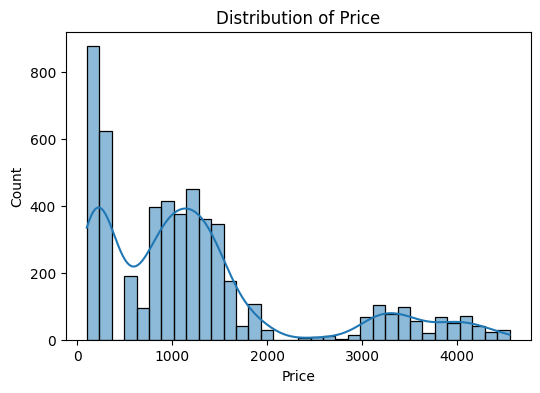

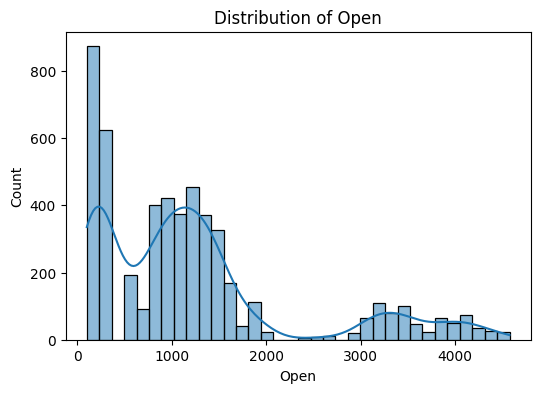

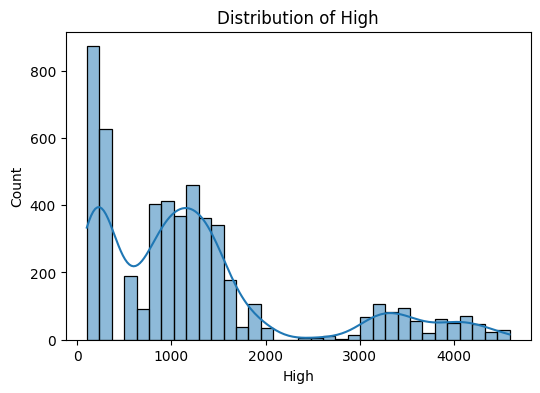

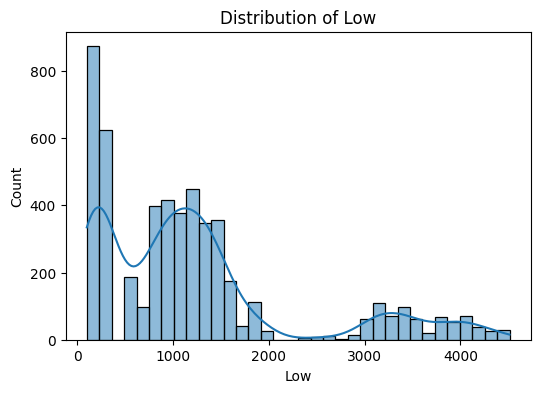

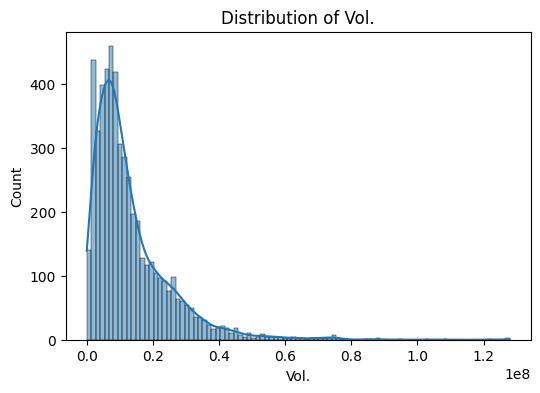

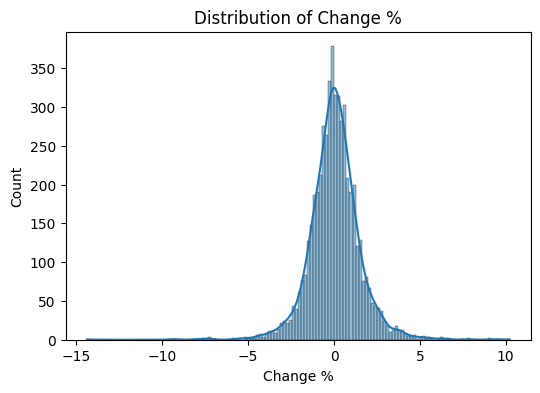

In [96]:
cols = ["Price", "Open", "High", "Low", "Vol.", "Change %"]

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=data, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## boxplot - to identify the outliers in the data

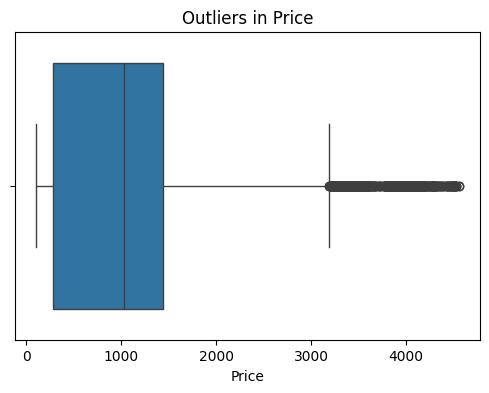

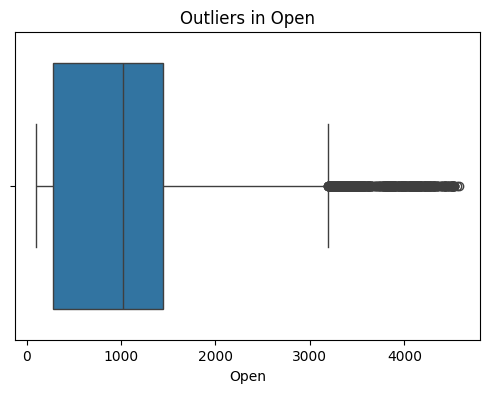

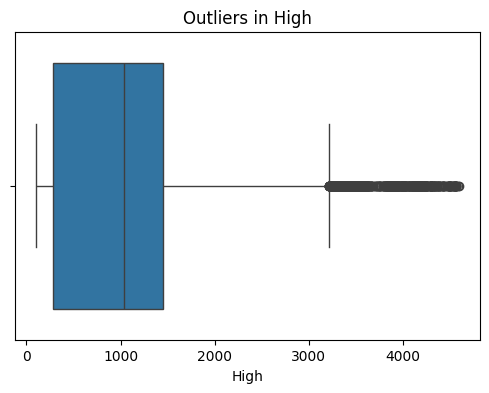

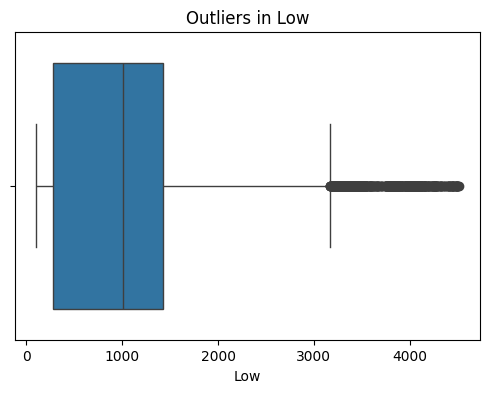

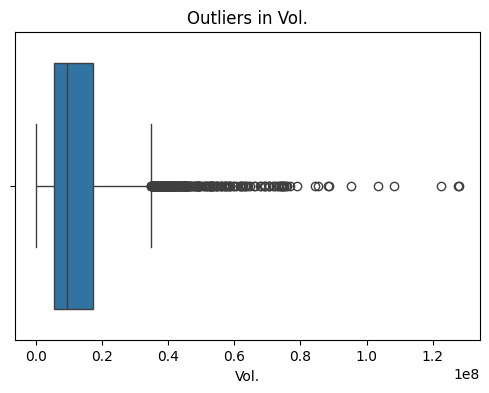

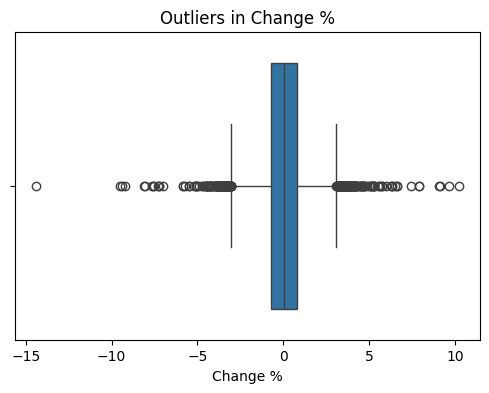

In [95]:
for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])
    plt.title(f"Outliers in {col}")
    plt.xlabel(col)
    plt.show()

## Scatter plot


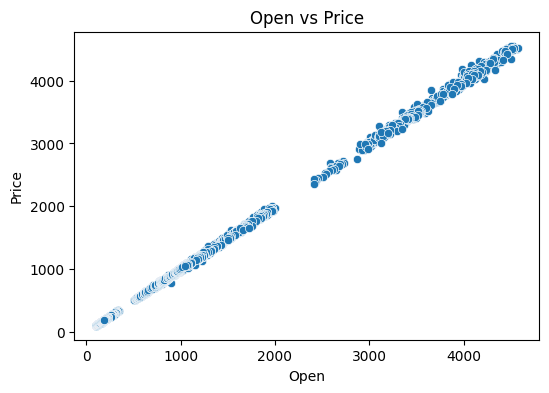

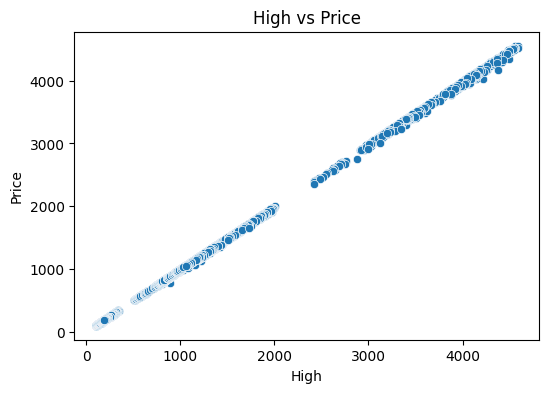

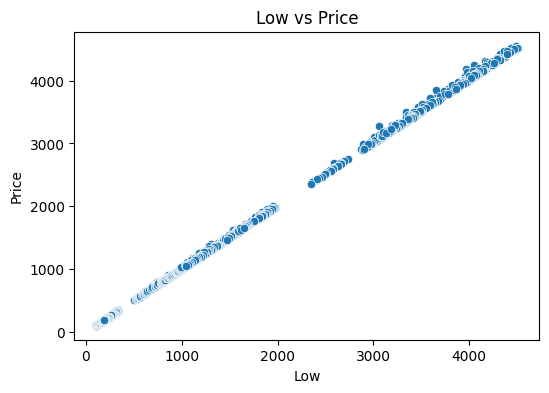

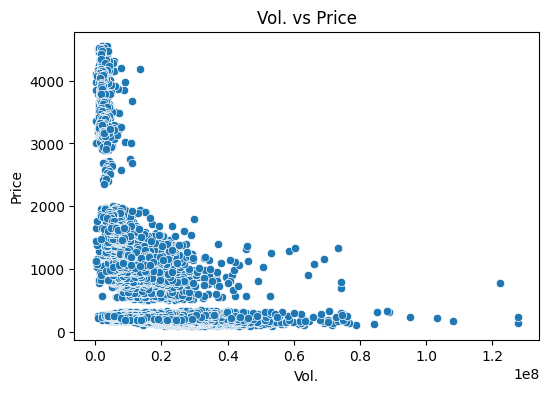

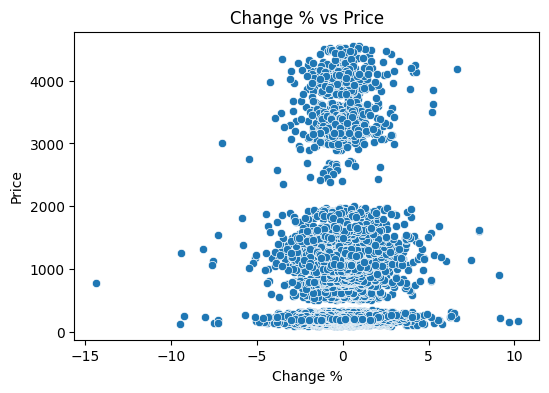

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

for i in ['Open', 'High', 'Low', 'Vol.', 'Change %']:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=data, x=i, y='Price')
    plt.title(f"{i} vs Price")
    plt.show()

In [98]:
data.select_dtypes(include = "number").columns

Index(['Price', 'Open', 'High', 'Low', 'Vol.', 'Change %'], dtype='object')

## correlation between heat map to interpret the relation and multicollenarity

In [99]:
corr = data[['Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']].corr()
print(corr)

             Price      Open      High       Low      Vol.  Change %
Price     1.000000  0.999844  0.999943  0.999933 -0.522600 -0.018757
Open      0.999844  1.000000  0.999924  0.999931 -0.522709 -0.028920
High      0.999943  0.999924  1.000000  0.999920 -0.521533 -0.023552
Low       0.999933  0.999931  0.999920  1.000000 -0.523782 -0.023553
Vol.     -0.522600 -0.522709 -0.521533 -0.523782  1.000000  0.048016
Change % -0.018757 -0.028920 -0.023552 -0.023553  0.048016  1.000000


In [65]:
corr = data.select_dtypes(include='number').corr()
print(corr)

             Price      Open      High       Low      Vol.  Change %
Price     1.000000  0.999844  0.999943  0.999933 -0.522600 -0.018757
Open      0.999844  1.000000  0.999924  0.999931 -0.522709 -0.028920
High      0.999943  0.999924  1.000000  0.999920 -0.521533 -0.023552
Low       0.999933  0.999931  0.999920  1.000000 -0.523782 -0.023553
Vol.     -0.522600 -0.522709 -0.521533 -0.523782  1.000000  0.048016
Change % -0.018757 -0.028920 -0.023552 -0.023553  0.048016  1.000000


## heatmap

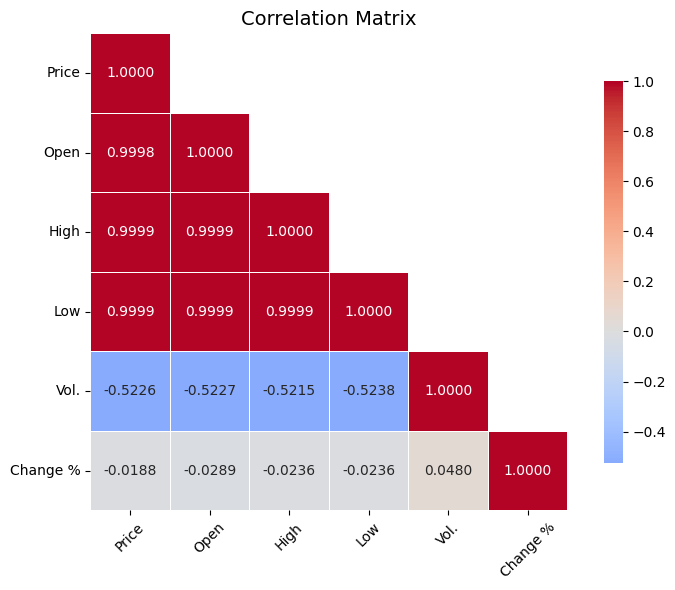

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Mask only the upper triangle ABOVE the diagonal
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".4f",
    mask=mask,
    linewidths=0.5,
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

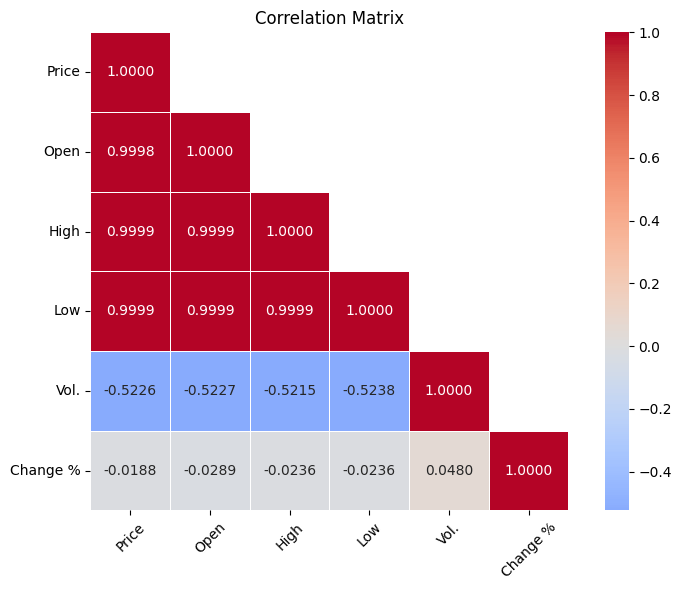

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Mask upper triangle (clean look)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".4f",
    mask=mask,
    linewidths=0.5,
    center=0,
    square=True
)

plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

## skipping handling missing values cause the data does not have any missing values 

## moving on to outlier handling // outlier treatment  we are skipping outlier treatment because it is not necessary for out data since stock market heavily relies on outliers 

In [73]:
data = pd.read_csv("final_cleaned_stock_data.csv")

## encoding the data - all that is left to do